In [1]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import numpy as np

import networkx as nx

from pathlib import Path
import os

from enum import Enum

from fame import *

import plotly.express as px
from matplotlib.pyplot import cm

import random


In [2]:
R_earth_km = 6371


In [3]:
# Space-Track Credentials
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')


In [4]:
tle_file_name_json = "all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [5]:
# tle_file_name_txt = "all_tles_20260130.txt"


In [6]:
# planet_satellites = []
# 14-19 decayed

instrument_types = [InstrumentType.RGB, InstrumentType.HYPERSPECTRAL, InstrumentType.SAR]

swaths_at_nadir_km = {
    "SKYSAT-A": 8, # https://www.eoportal.org/satellite-missions/skysat#SkySat.html.53, https://earth.esa.int/eogateway/missions/skysat#instruments-section
    "SKYSAT-B": 8,
    "SKYSAT-C1": 5.9,
    "SKYSAT-C2": 5.9,
    "SKYSAT-C3": 5.9,
    "SKYSAT-C4": 5.9,
    "SKYSAT-C5": 5.9,
    "SKYSAT-C6": 5.9,
    "SKYSAT-C7": 5.9,
    "SKYSAT-C8": 5.9,
    "SKYSAT-C9": 5.9,
    "SKYSAT-C10": 5.9,
    "SKYSAT-C11": 5.9,
    "SKYSAT-C12": 5.9,
    "SKYSAT-C13": 5.9,
    "PELICAN-3001": 8, # https://www.planet.com/constellations/pelican/
    "PELICAN-3009": 8,
    "PELICAN-300A": 8,
    "PELICAN-300B": 8,
    "PELICAN-5": 8,
    "PELICAN-6": 8,
    "TANAGER-4001": 18, # https://www.planet.com/constellations/tanager/
    "UMBRA-07": 8, # https://umbra.space/remote-sensing/scan-mode/
    "UMBRA-09": 8, 
    "UMBRA-10": 8,
    "UMBRA-11": 8, 
    "CAPELLA-11 (ACADIA-1)": 10, #https://support.capellaspace.com/what-are-capellas-collect-modes and https://geokom.ba/wp-content/uploads/2020/12/Capella_Space_SAR_System_Performance.pdf
    "CAPELLA-13 (ACADIA-3)": 10,
    "CAPELLA-14 (ACADIA-4)": 10,
    "CAPELLA-15 (ACADIA-5)": 10,
    "CAPELLA-16 (ACADIA-6)": 10,
    "CAPELLA-17 (ACADIA-7)": 10,
    "LOFT YAM-6": 19.8,
    "Ubotica CogniSat-6 HAMMER": 20,
    "Mission Control Persistence": 100,
    "AEROCUBE 18A": 80,
    "AEROCUBE 18B": 80,
}

skysat_satellites = [
    Satellite("SKYSAT-A", Orbital("SKYSAT 1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-B", Orbital("SKYSAT 2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2", Orbital("SKYSAT C2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C3", Orbital("SKYSAT C3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C4", Orbital("SKYSAT C4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C5", Orbital("SKYSAT C5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C6", Orbital("SKYSAT C6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C7", Orbital("SKYSAT C7", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C8", Orbital("SKYSAT C8", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C9", Orbital("SKYSAT C9", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
]
pelican_satellites = [
    Satellite("PELICAN-3001", Orbital("PELICAN-1 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("PELICAN-3009", Orbital("PELICAN-2 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("PELICAN-300A", Orbital("PELICAN-3 300A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("PELICAN-300B", Orbital("PELICAN-4 300B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("PELICAN-5", Orbital("PELICAN-5 300C", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("PELICAN-6", Orbital("PELICAN-6 300D", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),

]
tanager_satellites = [
    Satellite("TANAGER-4001", Orbital("TANAGER-1 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
]
# 1-6 and 8 decayed
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True),
]
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]


loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)]
ubotica_satellites = [Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)]
mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),]
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),   
]

for sat in skysat_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in pelican_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in tanager_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }

for sat in umbra_satellites:
    sat.isl_links = {s: 250 for s in umbra_satellites if s!=sat }

for sat in capella_acadia_satellites:
    sat.isl_links = {s: 250 for s in capella_acadia_satellites if s!=sat }

for sat in aerospace_corp_satellites:
    sat.isl_links = {s: 250 for s in aerospace_corp_satellites if s!=sat }


In [7]:
all_satellites = skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+loft_satellites+ubotica_satellites+mission_control_satellites

In [8]:
for _sat in all_satellites:
    _semi_major_axis = _sat.orbit.orbit_elements.semi_major_axis * pyorbital.orbital.A
    _mean_altitude = _semi_major_axis-pyorbital.orbital.A
    _fov = 2*np.atan2(swaths_at_nadir_km[_sat.name]/2, _mean_altitude)
    _sat.instrument_fov_rad = {InstrumentType.RGB: _fov}

In [9]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "midnightblue"
    if "PELICAN" in sat_name:
        return "mediumblue"
    if "TANAGER" in sat_name:
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name:
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "darkorange"
    # 
    if "LOFT" in sat_name:
        return "forestgreen"
    #
    if "Ubotica" in sat_name:
        return "lime"
    #
    if "Mission Control" in sat_name:
        return "orchid"
    return "red"
    
def constcolorer(constellation_name):
    # Planet: shades of blue
    if "PLANET" in constellation_name:
        return "blue"
    # Black
    if "UMBRA" in constellation_name:
        return "gray"
    # Yellow/orange
    if "CAPELLA" in constellation_name:
        return "darkorange"
    # 
    if "LOFT" in constellation_name:
        return "forestgreen"
    #
    if "Ubotica" in constellation_name:
        return "lime"
    #
    if "Mission Control" in constellation_name:
        return "orchid"
    return "red"

def satmarkerer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "p"
    if "PELICAN" in sat_name:
        return "p"
    if "TANAGER" in sat_name:
        return "p"
    # Black
    if "UMBRA" in sat_name:
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "D"
    # 
    if "LOFT" in sat_name:
        return "p"
    #
    if "Ubotica" in sat_name:
        return "p"
    #
    if "Mission Control" in sat_name:
        return "p"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}

constcolor = {sat.name: satmarkerer(sat.name) for sat in all_satellites}


In [10]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")

### Communication opportunities

In [11]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

In [12]:
min_time=dt.datetime.now(dt.timezone.utc)
max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)

# What is a workflow?

We had described a workflow as:
- A task or bag of tasks
- whose completion spawns other tasks (implicitly creating both a START_AFTER_END constraint, and an information dependency).

We need to handle two cases: (i) the next location is unknown and (ii) the next location is known, but there is a Boolean gate.
Do we want more complex constraints? It would be nice to have a CONCURRENT constraint. Or START_AFTER_START.
How about we stsart with the simple stuff?
We will then implement ~~two~~ three algorithms for scheduling.
- Priority heuristic
- ILP
- Network flow (as above) only for START_AFTER_END

Let's start defining the format.

A workflow is (i) a set of ObservationRequests with (ii) dependency constraints of the type START_AFTER_END, CONCURRENT, START_AFTER_START, (iii) Boolean constraints of the type START_IF_SUCCESSFUL, START_IF_FAILED (which imply START_AFTER_END dependency), and (iv) geometry constraints of the form DATA.
We distinguish the Boolean and geometry constriants because the latter does not allow early scheduling.

There is a recursive form of this. We will not use it initially, and use an interpreter to translate the unrolled form to the recursive form.

A set of (ObservationRequest, Dependency (dict with other ObsRequest as key, and obs type as value), BooleanConstraint (dict with other ObsRequest as key, and obs type as value), GeometryConstraint (dict with other ObsRequest as key, and obs type as value))

Note we are also implicitly defining an output format for observation requests' data products: these need to, at a minimum, return a boolean success, and (if required) geometric data information. That is really an execution constraint.


In [13]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")
min_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)
max_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)+ dt.timedelta(seconds=3600*24*2)

ship_location_timeline = Timeline(name="Ship location", initial_time=min_time, initial_value=1, initial_rate=-1./10800, min_value=-100, max_value=100)

# ship_location_timeline = Timeline(name="Ship location", initial_time=min_time, initial_value=1, initial_rate=0, min_value=-100, max_value=100)


obs_request_initial = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Initial RGB request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )

obs_request_followup_no = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Follow-up search request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )

obs_request_followup_yes = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Follow-up SAR request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.SAR
    )

constrained_initial_observation = ConstrainedObservationRequest(
    name = "Initial observation",
    observation_request=obs_request_initial,
    success_declarer=lambda data_product: len(data_product)>0,
    is_mandatory=True,
    timeline_constraints=[],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
)

constrained_followup_observation = ConstrainedObservationRequest(
    name = "Follow-up observation 1",
    observation_request=obs_request_followup_yes,
    task_constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER, constrained_initial_observation),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_initial_observation),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_initial_observation),
    ],
    timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0.),],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.),],
)

constrained_followup_search = ConstrainedObservationRequest(
    name = "Follow-up search 1",
    observation_request=obs_request_followup_no,
    task_constraints=[
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER, constrained_initial_observation),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_initial_observation),
    ],
    timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
)

constrained_followup_observation_later = ConstrainedObservationRequest(
    name = "Follow-up observation 2",
    observation_request=obs_request_followup_yes,
    task_constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_observation, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_observation, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_search, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_search, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_followup_observation),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_followup_search),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_followup_observation),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_followup_search),
    ],
    timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0),],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
    schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
)

constrained_followup_search_later = ConstrainedObservationRequest(
    name = "Follow-up search 2",
    observation_request=obs_request_followup_no,
    task_constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_observation, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_observation, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_search, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_search, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_followup_observation),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_followup_search),
    ],
    timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
)

constrained_followup_observation_later2 = ConstrainedObservationRequest(
    name = "Follow-up observation 3",
    observation_request=obs_request_followup_yes,
    task_constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_observation_later, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_observation_later, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_search_later, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_search_later, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_followup_observation_later),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_followup_search_later),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_followup_observation_later),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_followup_search_later),
    ],
    timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0),],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
    schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
)

constrained_followup_search_later2 = ConstrainedObservationRequest(
    name = "Follow-up search 3",
    observation_request=obs_request_followup_no,
    task_constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_observation_later, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_observation_later, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_search_later, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_search_later, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_followup_observation_later),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_followup_search_later),
    ],
    timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
)



workflow = Workflow(
    constrained_observation_requests=[
        constrained_initial_observation,
        constrained_followup_observation,
        constrained_followup_search,
        constrained_followup_observation_later,
        constrained_followup_search_later,
        constrained_followup_observation_later2,
        constrained_followup_search_later2,
    ],
    timelines = [ship_location_timeline,],
    )

   [Scheduler] WG: MultiDiGraph with 7 nodes and 37 edges
   [Scheduler] Nodes to visit: [Initial observation with 0 task constraints]
   [Scheduler] Current request: Initial observation with 0 task constraints
   [Scheduler] This request is still in play, let's revisit it
   [Scheduler] This request has 2 children: [Follow-up observation 1 with 5 task constraints, Follow-up search 1 with 4 task constraints]
Skipping task constraints for child Follow-up observation 1 with 5 task constraints, currently unscheduled
Skipping task constraints for child Follow-up search 1 with 4 task constraints, currently unscheduled
   [Scheduler] This request has 0 parents: []
Found opportunities from time 2026-04-21 21:16:44.958731 to 2026-04-23 21:16:44.958755: {Request Initial RGB request in Rotterdam_trimmed: {SKYSAT-A: [Pass start: 2026-04-22 09:18:54.629673, highest: 2026-04-22 09:19:54.623321, fall: 2026-04-22 09:21:03.704250, Pass start: 2026-04-22 20:05:53.783712, highest: 2026-04-22 20:06:54.65

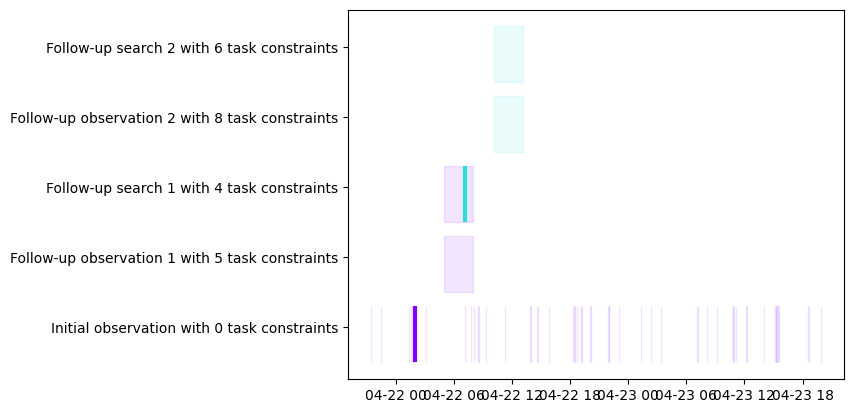

In [14]:
wg, tg = build_workflow_graph(workflow=workflow)

wg = greedy_schedule_workflow(workflow_graph=wg, timeline_graph=tg, satellites=all_satellites)

for request in workflow.constrained_observation_requests:
    if request in wg.nodes():
        print(f"Request {request}: opportunity {wg.nodes[request]['observation_opportunity']}")
    else:
        print(f"Request {request} was not scheduled")
# wg.nodes[obs_request_followup_no]

plot_workflow_schedule(wg)

In [15]:
wg_ilp, tg_ilp = build_workflow_graph(workflow=workflow)


In [16]:
wg_ilp = ilp_schedule_workflow(workflow_graph=wg_ilp, timeline_graph=tg_ilp, satellites=all_satellites, verbose=3)


   [Scheduler] WG: MultiDiGraph with 7 nodes and 37 edges
    [Scheduler] Solved to optimality; objective value = 50.17050169987931
    [Scheduler]  Initial observation with 0 task constraints_SKYSAT-C2_Pass start: 2026-04-22 07:44:25.561940, highest: 2026-04-22 07:45:00.172019, fall: 2026-04-22 07:45:34.782098  =  1.0
    [Scheduler]  Follow-up observation 1 with 5 task constraints_UMBRA-09_Pass start: 2026-04-22 11:46:27.095578, highest: 2026-04-22 11:47:32.162281, fall: 2026-04-22 11:48:30.166562  =  1.0
    [Scheduler]  Follow-up search 1 with 4 task constraints_PELICAN-5_Pass start: 2026-04-22 11:14:57.727015, highest: 2026-04-22 11:15:23.125957, fall: 2026-04-22 11:15:48.524898  =  1.0
    [Scheduler]  Follow-up observation 3 with 8 task constraints_CAPELLA-16 (ACADIA-6)_Pass start: 2026-04-21 21:58:53.199468, highest: 2026-04-21 21:59:42.204680, fall: 2026-04-21 22:00:31.209891  =  1.0
    [Scheduler]  Follow-up search 3 with 6 task constraints_SKYSAT-C4_Pass start: 2026-04-22 0

In [17]:

for request in workflow.constrained_observation_requests:
    if request in wg_ilp.nodes():
        print(f"Request {request}: opportunity {request.observation_opportunity}")
    else:
        print(f"Request {request} was not scheduled")
# wg.nodes[obs_request_followup_no]

Request Initial observation with 0 task constraints: opportunity Observation  at 2026-04-22 07:45:00.172019 with InstrumentType.RGB. Look angle 287.58140253354446 | 51.9238051358721 az/dec deg, zenith angle 61.86210936833776 deg, range 563.6480781068075 km, duration 0:01:00
Request Follow-up observation 1 with 5 task constraints: opportunity Observation  at 2026-04-22 11:47:32.162281 with InstrumentType.RGB. Look angle 278.45386947036906 | 70.75921592921102 az/dec deg, zenith angle 39.713163377494155 deg, range 552.962132061211 km, duration 0:01:00
Request Follow-up search 1 with 4 task constraints: opportunity Observation  at 2026-04-22 11:15:23.125957 with InstrumentType.RGB. Look angle 289.1134051500392 | 47.88202155302336 az/dec deg, zenith angle 40.110754259429456 deg, range 638.6857264206901 km, duration 0:01:00
Request Follow-up observation 2 with 8 task constraints: opportunity None
Request Follow-up search 2 with 6 task constraints: opportunity None
Request Follow-up observati

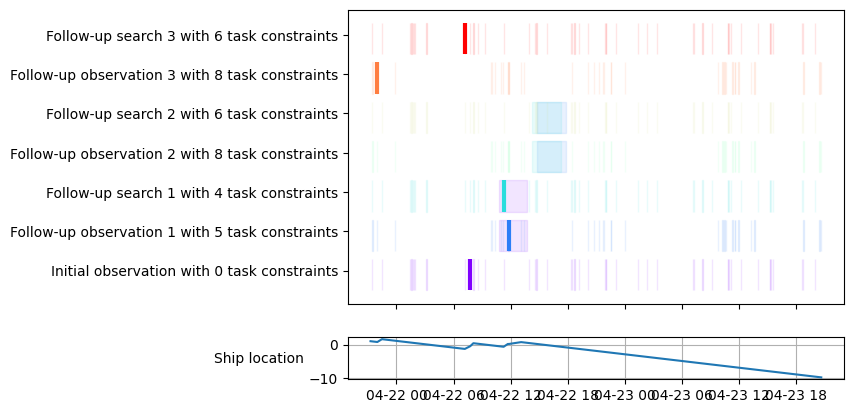

In [18]:


plot_workflow_schedule(wg_ilp, tg_ilp)


In [19]:
dt_h = 3

ship_location_timeline_longer = Timeline(name="Do we know where the ship is?", initial_time=min_time, initial_value=1, initial_rate=-1./10800, min_value=-100, max_value=100)


constrained_initial_observation_longer = ConstrainedObservationRequest(
    name = "Initial observation",
    observation_request=obs_request_initial,
    success_declarer=lambda data_product: len(data_product)>0,
    is_mandatory=True,
    timeline_constraints=[],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_longer, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
)

workflow_longer_reqs = [constrained_initial_observation_longer]


# If the prior is successful, do a SAR request
for h_ix in list(range(dt_h,24,dt_h)):

    obs_task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation_longer, {'offset': dt.timedelta(seconds=3600*h_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation_longer, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
            # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, workflow_longer_reqs[-1]), # Start if the previous search was successful
            # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
        ]
    # if len(workflow_longer_reqs)>1:
    #     obs_task_constraints.append(
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, workflow_longer_reqs[-2]), # Start if the previous observation was successful
    #     )
    #     obs_task_constraints.append(
    #         Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-2]),
    #     )

    constrained_followup_observation_later = ConstrainedObservationRequest(
        name="Follow-up observation {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_yes,
        task_constraints = obs_task_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        success_declarer=lambda data_product: len(data_product)>0,
        timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline_longer, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0),],
        timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_longer, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],

    )

    srch_task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation_longer, {'offset': dt.timedelta(seconds=3600*h_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation_longer, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
            # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, workflow_longer_reqs[-1]), # Start if the previous search was successful
        ]
    # if len(workflow_longer_reqs)>1:
    #     srch_task_constraints.append(
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, workflow_longer_reqs[-2]), # Start if the previous observation failed (or was not scheduled)
    #     )

    # If the prior fails, do a search
    constrained_followup_search_later = ConstrainedObservationRequest(
        name="Follow-up search {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_no,
        task_constraints = srch_task_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        success_declarer=lambda data_product: len(data_product)>0,
        timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline_longer, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
        timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_longer, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],

    )

    workflow_longer_reqs.append(constrained_followup_observation_later)
    workflow_longer_reqs.append(constrained_followup_search_later)

def longer_timeline_updater(current_time: dt.datetime, requests: list[ConstrainedObservationRequest], timelines: list[Timeline], max_time_without_observations: dt.timedelta=dt.timedelta(seconds=10800)):
    # What time is it?
    # Did we have a successful search or imaging in the recent past?
    # If we did, set timeline start to 1
    # If we did not, set timeline start to 0
    # Keep the current rate
    ship_position_is_known = False
    for current_request in requests:
        if (current_request.completed is True):
            if (current_request.successful_execution is True):
                if (current_time-current_request.observation_opportunity.time)<max_time_without_observations:
                    ship_position_is_known = True
                    break
    
    ship_position_timeline = timelines[0]
    if ship_position_is_known:
        current_measured_value = 1
    else:
        current_measured_value = 0

    _current_estimated_value, _current_estimated_rate = current_estimated_knowledge_and_rate = ship_position_timeline._get_value_and_rate_at(current_time)

    ship_position_timeline.reset_timeline(current_time, current_measured_value, _current_estimated_rate)

    return timelines

workflow_longer = Workflow(
    constrained_observation_requests=workflow_longer_reqs,
    timelines = [ship_location_timeline_longer,],
    timeline_updater=longer_timeline_updater
)

In [20]:
# wg_longer, tg_longer = build_workflow_graph(workflow=workflow_longer)

# wg_longer = greedy_schedule_workflow(workflow_graph=wg_longer, timeline_graph=tg_longer, satellites=all_satellites)

# plot_workflow_schedule(wg_longer)

In [21]:
wg_longer_ilp, tg_longer_ilp = build_workflow_graph(workflow=workflow_longer)




In [22]:
wg_longer_ilp = ilp_schedule_workflow(workflow_graph=wg_longer_ilp, timeline_graph=tg_longer_ilp, satellites=all_satellites)


   [Scheduler] WG: MultiDiGraph with 15 nodes and 28 edges
   [Scheduler] Request: Initial observation with 0 task constraints
Considering timeline Timeline Do we know where the ship is? with 2 impacts 
Considering timeline Timeline Do we know where the ship is? with 3 impacts 
Considering timeline Timeline Do we know where the ship is? with 4 impacts 
Considering timeline Timeline Do we know where the ship is? with 5 impacts 
Considering timeline Timeline Do we know where the ship is? with 6 impacts 
Considering timeline Timeline Do we know where the ship is? with 7 impacts 
Considering timeline Timeline Do we know where the ship is? with 8 impacts 
Considering timeline Timeline Do we know where the ship is? with 9 impacts 
Considering timeline Timeline Do we know where the ship is? with 10 impacts 
Considering timeline Timeline Do we know where the ship is? with 11 impacts 
Considering timeline Timeline Do we know where the ship is? with 12 impacts 
Considering timeline Timeline Do w

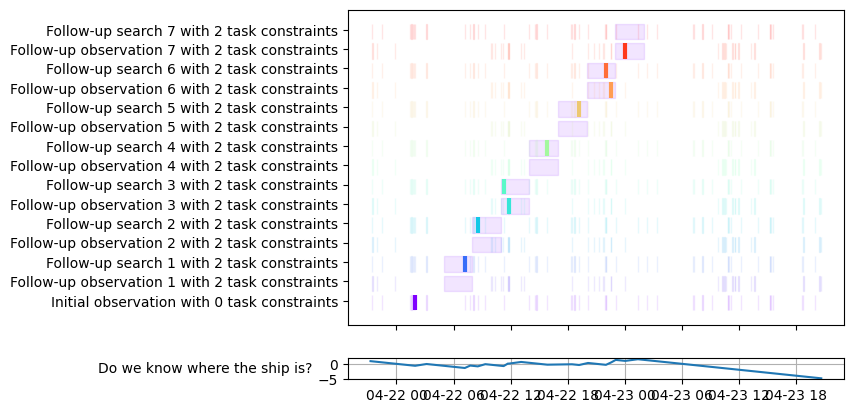

In [23]:
plot_workflow_schedule(wg_longer_ilp, tg_longer_ilp)

In [24]:
workflow_relative_reqs = [constrained_initial_observation]

dt_h = 3

for h_ix in list(range(dt_h,24,dt_h)):
    _task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, workflow_relative_reqs[-1], {'offset': dt.timedelta(seconds=3600*dt_h)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, workflow_relative_reqs[-1], {'offset': dt.timedelta(seconds=3600*(2*dt_h))}),
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, workflow_relative_reqs[-1]),
            Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_relative_reqs[-1]),
        ]
    # if len(workflow_relative)>1:
    #     _constraints.extend([
    #         Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, workflow_relative[-2], {'offset': dt.timedelta(seconds=3600*dt_h)}),
    #         Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, workflow_relative[-2], {'offset': dt.timedelta(seconds=3600*(2*dt_h))}),
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, workflow_relative[-2]),
    #         Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_relative[-2]),
    #     ])

    constrained_followup_observation_later = ConstrainedObservationRequest(
        name="Follow-up observation {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_yes,
        task_constraints = _task_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
    )

    _task_constraints_s = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, workflow_relative_reqs[-1], {'offset': dt.timedelta(seconds=3600*dt_h)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, workflow_relative_reqs[-1], {'offset': dt.timedelta(seconds=3600*(2*dt_h))}),
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, workflow_relative_reqs[-1])
    ]
    # if len(workflow_relative)>1:
    #     _constraints_s.extend([
    #         Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, workflow_relative[-2], {'offset': dt.timedelta(seconds=3600*dt_h)}),
    #         Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, workflow_relative[-2], {'offset': dt.timedelta(seconds=3600*(2*dt_h))}),
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, workflow_relative[-2]),
    #     ])
    constrained_followup_search_later = ConstrainedObservationRequest(
        name="Follow-up search {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_no,
        task_constraints = _task_constraints_s,
    )

    workflow_relative_reqs.append(constrained_followup_observation_later)
    workflow_relative_reqs.append(constrained_followup_search_later)

workflow_relative = Workflow(
    constrained_observation_requests=workflow_relative_reqs
)

   [Scheduler] WG: MultiDiGraph with 15 nodes and 49 edges
   [Scheduler] Nodes to visit: [Initial observation with 0 task constraints]
   [Scheduler] Current request: Initial observation with 0 task constraints
   [Scheduler] This request is still in play, let's revisit it
   [Scheduler] This request has 2 children: [Follow-up observation 1 with 4 task constraints, Follow-up search 1 with 3 task constraints]
Skipping task constraints for child Follow-up observation 1 with 4 task constraints, currently unscheduled
Skipping task constraints for child Follow-up search 1 with 3 task constraints, currently unscheduled
   [Scheduler] This request has 0 parents: []
Found opportunities from time 2026-04-21 21:16:44.958731 to 2026-04-23 21:16:44.958755: {Request Initial RGB request in Rotterdam_trimmed: {SKYSAT-A: [Pass start: 2026-04-22 09:18:54.629673, highest: 2026-04-22 09:19:54.623321, fall: 2026-04-22 09:21:03.704250, Pass start: 2026-04-22 20:05:53.783712, highest: 2026-04-22 20:06:54.6

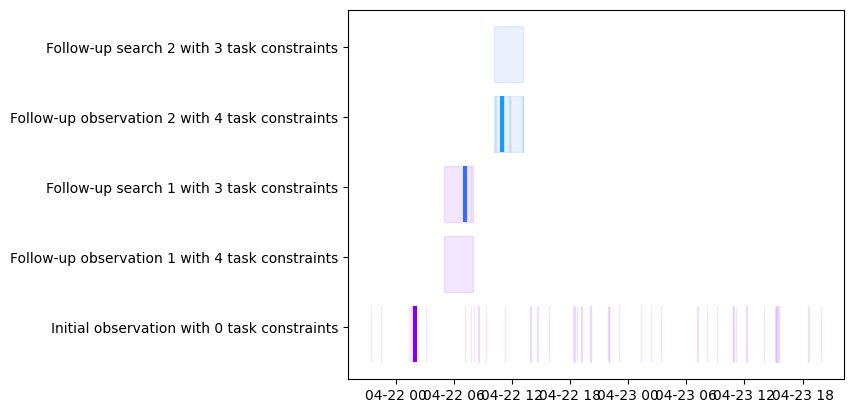

In [25]:
wg_relative, tg_relative = build_workflow_graph(workflow=workflow_relative)

wg_relative = greedy_schedule_workflow(workflow_graph=wg_relative, timeline_graph=tg_relative, satellites=all_satellites)


# wg_relative_scheduled = greedy_schedule_workflow(workflow=workflow_relative, satellites=all_satellites)
plot_workflow_schedule(wg_relative)

   [Scheduler] WG: MultiDiGraph with 15 nodes and 49 edges
   [Scheduler] Request: Initial observation with 0 task constraints
Considering timeline Timeline Ship location with 248 impacts 
Considering timeline Timeline Ship location with 249 impacts 
Considering timeline Timeline Ship location with 250 impacts 
Considering timeline Timeline Ship location with 251 impacts 
Considering timeline Timeline Ship location with 252 impacts 
Considering timeline Timeline Ship location with 253 impacts 
Considering timeline Timeline Ship location with 254 impacts 
Considering timeline Timeline Ship location with 255 impacts 
Considering timeline Timeline Ship location with 256 impacts 
Considering timeline Timeline Ship location with 257 impacts 
Considering timeline Timeline Ship location with 258 impacts 
Considering timeline Timeline Ship location with 259 impacts 
Considering timeline Timeline Ship location with 260 impacts 
Considering timeline Timeline Ship location with 261 impacts 
Consi

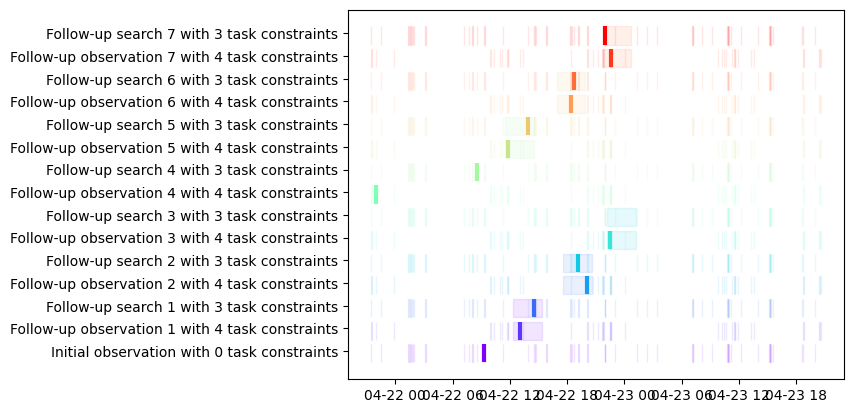

In [26]:
wg_relative_ilp, tg_relative_ilp = build_workflow_graph(workflow=workflow_relative)

wg_relative_ilp = ilp_schedule_workflow(workflow_graph=wg_relative_ilp, timeline_graph=tg_relative_ilp, satellites=all_satellites)


# wg_relative_scheduled = greedy_schedule_workflow(workflow=workflow_relative, satellites=all_satellites)
plot_workflow_schedule(wg_relative_ilp)